In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [1]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "1edefaec0732d11db50b993ba60539510cc55334"
from tools.search_tools import SearchTools




In [2]:
import asyncio
import autogen
import os
import httpx
from typing import Optional, List, Dict, Tuple, Union
import random  # noqa E402

import matplotlib.pyplot as plt  # noqa E402
import networkx as nx  # noqa E402

import autogen  # noqa E402
from autogen.agentchat.conversable_agent import ConversableAgent  # noqa E402
from autogen.agentchat.assistant_agent import AssistantAgent  # noqa E402
from autogen.agentchat.groupchat import GroupChat  # noqa E402
from autogen.graph_utils import visualize_speaker_transitions_dict 

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-REDACTED"

# Define a custom HTTP client
class MyHttpClient(httpx.Client):
    def __deepcopy__(self, memo):
        return self
    
config_list = [{"model": "gpt-3.5-turbo", "api_key": os.environ["OPENAI_API_KEY"]}]

# Configure the language model
# Configure the language model
llm_config = {
    "config_list": [
        {
            "model": "mistral",
            "api_type": "ollama",
            "client_host": "https://a4qj546ajyr2o9-11434.proxy.runpod.net",
        }
    ]
}




class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the received message in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        # Call the parent class's receive method to handle the message
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the agent's response in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        # Call the parent class's send method to send the message
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        # Limit to the last 10 messages from memory
        recent_memory = self.memory[-10:]
        # Prepare the conversation context
        conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages + "choose who do you want to speak next"
        # Generate a response using the language model
        response = self.llm.generate(conversation)
        # Store the response in memory
        self.memory.append({"role": "assistant", "content": response})
        return response


def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message="A human admin who terminates the chat when the leader agent sends a message with 'TERMINATE' mentioned it it",
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config,
)

Leader = MemoryAgent(
    name="Leader",
    system_message=(
        "You Lead a Maths_Expert and are tasked to solve a mathematical problem\n"
        "DO NOT SOLVE THE PROBLEM YOURSELF ONLY EXPLAIN IT TO THE EXPERT"
        "When you arrive on the final answer write it in a single line and say'TERMINATE'.\n"
        "** Always Select the next speaker **\n"

    ),
    llm_config=llm_config
)


# AgentA = MemoryAgent(
#     name="Algebra_Expert",
#     system_message=(
#         "You are an expert in mathematics specialising in algebra\n"
#         "Collaborate with other experts to solve the problem\n"
#         "Be concise, follow Leader.\n"
#         "** Always Select the next speaker **\n"
#     ),
#     llm_config=llm_config
# )


# AgentB = MemoryAgent(
#     name="Geometry_Expert",
#     system_message=(
#         "You are an expert in mathematics specialising in geometry\n"
#         "Collaborate with other experts to solve the problem\n"
#         "Be concise, follow Leader.\n"
#         "** Always Select the next speaker **\n"
#     ),
#     llm_config=llm_config
# )


# AgentC = MemoryAgent(
#     name="Arithmetic_Expert",
#     system_message=(
#         "You are an expert in mathematics specialising in arithematics\n"
#         "Collaborate with other experts to solve the problem\n"
#         "Be concise, follow Leader.\n"
#         "** Always Select the next speaker **\n"
#     ),
#     llm_config=llm_config
# )



# AgentD = MemoryAgent(
#     name="Probability_Expert",
#     system_message=(
#         "You are an expert in mathematics specialising in probability\n"
#         "Collaborate with other experts to solve the problem\n"
#         "Be concise, follow Leader.\n"
#         "** Always Select the next speaker **\n"
#     ),
#     llm_config=llm_config
# )


AgentB = MemoryAgent(
    name="Maths_Expert",
    system_message=(
        "You are an expert in mathematics having knowledge about every field\n"
        "Understand the problem given to you properly and solve the mathematical problem\n"
        "** Always Select the next speaker **\n"
    ),
    llm_config=llm_config
)


Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=( 
        "You are responsible for executing the tools"
    ),
    # llm_config={"config_list": [{"model": "gpt-4o-mini", "api_key": os.environ.get("OPENAI_API_KEY")}]}
    llm_config=llm_config,
)


In [3]:
import requests
import json

def query_ollama(prompt, model="mistral"):
    url = "https://a4qj546ajyr2o9-11434.proxy.runpod.net/api/generate"  # Ensure correct endpoint
    payload = {"model": model, "prompt": prompt}
    
    try:
        response = requests.post(url, json=payload)
        response.raise_for_status()  # Check for HTTP errors
        
        # Process response line by line 
        result = ""
        for line in response.text.splitlines():
            try:
                line_data = json.loads(line)
                result += line_data.get("response", "")
                if line_data.get("done", False):
                    break
            except json.JSONDecodeError:
                continue  # Ignore lines that aren't valid JSON
                
        return result.strip()  # Return the concatenated response
    except requests.exceptions.RequestException as e:
        return {"error": "Request failed", "details": str(e)}

In [4]:
# # Add a global or class-level variable to track the first call
# is_first_call = True  # This flag tracks if the function is being called for the first time

# def custom_speaker_selection_func(last_speaker, groupchat):
#     global is_first_call

#     # If this is the first call, return the leader agent
#     if is_first_call:
#         is_first_call = False  # Reset the flag after the first call
#         print("First call detected. Setting speaker to Leader agent.")
#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Agent3" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Access the last message in the group chat
#     last_message = groupchat.messages[-1]
#     print(f"Last message content: {last_message}")

#     # Prepare the input for the LLM
#     prompt = (
#     "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Summarizer_Agent_1, Summarizer_Agent_2, Summarizer_Agent_3 and Leader. "
#     "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
#     f"The last message is: {last_message.get('content', '')}"
#     )

#     # Analyze the message using the local LLM
#     response = query_ollama(prompt)
#     print(f"LLM response: {response}")

#     # Extract the relevant text from the response dictionary
#     next_speaker_name = response  # Replace 'text' with the correct key

#     # Find the corresponding agent in the group chat
#     for agent in groupchat.agents:
#         if agent.name == next_speaker_name:
#             return agent

#     # If no valid agent is found, return None or a default fallback
#     print(f"No valid agent found for the name: {next_speaker_name}")
#     return None


In [5]:
# Global variables to track the first call and the call count
is_first_call = True  # Tracks if this is the first call
call_count = 0        # Tracks the number of times the function has been called

def custom_speaker_selection_func(last_speaker, groupchat):
    global is_first_call, call_count

    # If this is the first call, return the leader agent
    if is_first_call:
        is_first_call = False  # Reset the flag after the first call
        print("First call detected. Setting speaker to Leader agent.")

        for agent in groupchat.agents:
            if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
                return agent
        print("Error: Leader agent not found in the agents list.")
        return None  # Handle the case where the leader agent is not found

    # # Increment the call count
    # call_count += 1

    # # If this is the 5th call, return the Result_Provider agent
    # if call_count == 5:
    #     print(f"5th call detected (call count: {call_count}). Setting speaker to Result_Provider agent.")
    #     for agent in groupchat.agents:
    #         if agent.name == "Result_Provider":
    #             return agent
    #     print("Error: Result_Provider agent not found in the agents list.")
    #     return None  # Handle the case where the Result_Provider agent is not found


    if call_count % 3 == 0:
        print(f"7th call detected (call count: {call_count}). Setting speaker to Leader agent.")
        for agent in groupchat.agents:
            if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
                return agent
        print("Error: Leader agent not found in the agents list.")
        return None  # Handle the case where the leader agent is not found

    # Access the last message in the group chat
    last_message = groupchat.messages[-1]
    print(f"Last message content: {last_message}")

    # Prepare the input for the LLM
    prompt = (
        "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Maths_Expert and Leader. \n"
        "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
        f"The last message is: {last_message.get('content', '')}"
    )

    # Analyze the message using the local LLM
    response = query_ollama(prompt)
    print(f"LLM response: {response}")

    # Extract the relevant text from the response dictionary
    next_speaker_name = response.strip()  # Use .strip() to remove any extra spaces or newlines

    # Find the corresponding agent in the group chat
    for agent in groupchat.agents:
        if agent.name == next_speaker_name:
            return agent

    # If no valid agent is found, return None or a default fallback
    print(f"No valid agent found for the name: {next_speaker_name}")
    return None


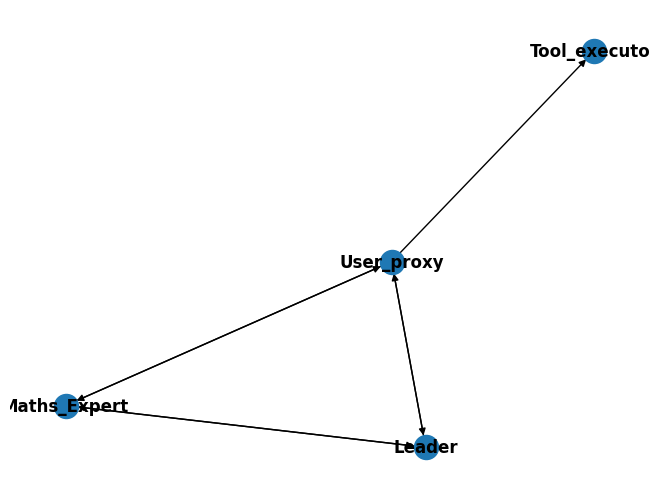

In [6]:
# Define your agents
agents = [AgentB, Leader, user_proxy, Agent5]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [7]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=100,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
    speaker_selection_method=custom_speaker_selection_func,
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [8]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [9]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'output.xlsx'
data = pd.read_excel(file_path)

# Select the column you want to print
column_data = data['question'][:5]
answers = []

# Process each question
for index, value in enumerate(column_data, start=1):
    print(value)
    initial_message = f"The question you have to solve is - {value}"

    # Initiate the conversation
    user_proxy.initiate_chat(manager, message=initial_message)
    last_message = group_chat.messages[-1] if group_chat.messages else None
    if last_message:
        answers.append(last_message['content'])

# Add the answers as a new column to the DataFrame
data.loc[:len(answers)-1, 'answers'] = answers

# Save the updated DataFrame back to the Excel file
data.to_excel(file_path, index=False)

Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
User_proxy (to chat_manager):

The question you have to solve is - Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

--------------------------------------------------------------------------------
[Maths_Expert] Received message from chat_manager: {'content': 'The question you have to solve is - Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'role': 'user', 'name': 'User_proxy'}
[Leader] Received message from chat_manager: {'content': 'The question you have to solve is - Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April an

In [11]:
initial_message = (
    "The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?"
)

# Initiate the conversation
user_proxy.initiate_chat(manager, message=initial_message)


User_proxy (to chat_manager):

The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?

--------------------------------------------------------------------------------
[Maths_Expert] Received message from chat_manager: {'content': 'The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?', 'role': 'user', 'name': 'User_proxy'}
[Leader] Received message from chat_manager: {'content': 'The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $

ChatResult(chat_id=None, chat_history=[{'content': 'The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?', 'role': 'assistant', 'name': 'User_proxy'}, {'content': " The amount of money Betty's parents are giving her is $15, and her grandparents are giving her twice as much as her parents, so they will give her 2*$15 = $30. In total, Betty now has $15 + $30 = $45. The wallet costs $100, so the difference in the amount she needs and the amount she currently has is $100 - $45 = $55.\n\nTERMINATE.", 'name': 'Leader', 'role': 'user'}, {'content': " The amount of money Betty's parents are giving her is $15, and her grandparents are giving her twice as much as her parents, so they will give her 2*$15 = $30. In total, Betty now has $15 + $30 = $45. The wallet costs $

In [12]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content:  The amount of money Betty's parents are giving her is $15, and her grandparents are giving her twice as much as her parents, so they will give her 2*$15 = $30. In total, Betty now has $15 + $30 = $45. The wallet costs $100, so the difference in the amount she needs and the amount she currently has is $100 - $45 = $55.

TERMINATE.


In [13]:
initial_message = (
    "The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?"
)

# Initiate the conversation
user_proxy.initiate_chat(manager, message=initial_message)

User_proxy (to chat_manager):

The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?

--------------------------------------------------------------------------------
[Maths_Expert] Received message from chat_manager: {'content': 'The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?', 'role': 'user', 'name': 'User_proxy'}
[Leader] Received message from chat_manager: {'content': 'The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $

ChatResult(chat_id=None, chat_history=[{'content': 'The maths problem is - Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?', 'role': 'assistant', 'name': 'User_proxy'}, {'content': " The amount of money Betty's parents are giving her is $15, and her grandparents are giving her twice as much as her parents, so they will give her 2*$15 = $30. In total, Betty now has $15 + $30 = $45. The wallet costs $100, so the difference in the amount she needs and the amount she currently has is $100 - $45 = $55.\n\nTERMINATE.", 'name': 'Leader', 'role': 'user'}, {'content': " The amount of money Betty's parents are giving her is $15, and her grandparents are giving her twice as much as her parents, so they will give her 2*$15 = $30. In total, Betty now has $15 + $30 = $45. The wallet costs $

In [14]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [15]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Initialize the Llama 3.1 model
llm = ChatOpenAI(
    model="llama3.1",
    base_url="http://44.221.48.158:11434/v1"
)

def structure_logs_with_local_llm(file_path, initial_message):
    """
    Reads chat logs from a file and generates a structured summary.

    Args:
        file_path (str): Path to the chat log file.
        initial_message (str): The initial task or prompt for context.

    Returns:
        str: The structured summary generated by the LLM.
    """
    # Read the chat logs from the file
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            log_context = file.read()
    except FileNotFoundError:
        return "Error: The specified file was not found."
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

    # Prepare the messages for the LLM
    messages = [
        {
            "role": "system",
            "content": (
                "You are a professional chat summarizer who goes through the entire chat and creates a proper summary based on the '{initial_message}'."
            )
        },
        {
            "role": "user",
            "content": (
                f"Convert the following agent logs into a structured format and into a proper summarized final output "
                f"based on the task '{initial_message}'.\n\nLogs:\n{log_context}"
            )
        }
    ]

    # Generate the structured summary using the LLM
    try:
        response = llm.invoke(messages)
        if isinstance(response, AIMessage):
            structured_summary = response.content
        else:
            structured_summary = "Unexpected response type from the model."
    except Exception as e:
        structured_summary = f"An error occurred during LLM processing: {e}"

    return structured_summary


In [16]:
# Define the path to your chat log file and the initial task message
file_path = 'chat.txt'
initial_message = 'Design a comprehensive digital marketing course.'

# Generate the structured summary
summary = structure_logs_with_local_llm(file_path, initial_message)

# Output the summary
print(summary)

An error occurred during LLM processing: Request timed out.
